In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [11]:
df_1 = pd.read_parquet("data/dataset_1.parquet")
df_2 = pd.read_parquet("data/dataset_2.parquet")
df_3 = pd.read_parquet("data/dataset_3.parquet")

In [12]:
df_1.head()

,site_name,delivery_time,production,installed_capacity
0,Nobelwind Offshore Windpark,2022-12-31 23:00:00+00:00,162.7175,165.0
1,Nobelwind Offshore Windpark,2023-01-01 00:00:00+00:00,162.6850,165.0
2,Nobelwind Offshore Windpark,2023-01-01 01:00:00+00:00,162.6800,165.0
3,Nobelwind Offshore Windpark,2023-01-01 02:00:00+00:00,162.7300,165.0
4,Nobelwind Offshore Windpark,2023-01-01 03:00:00+00:00,162.7125,165.0


In [13]:
df_3.delivery_time.unique()

array(['2023-01-01 00:00:00+00:00', '2023-01-01 01:00:00+00:00',
       '2023-01-01 02:00:00+00:00', ..., '2026-02-20 21:00:00+00:00',
       '2026-02-20 22:00:00+00:00', '2026-02-20 23:00:00+00:00'],
      shape=(27528,), dtype=object)

In [14]:
df_1.delivery_time.unique()

<DatetimeArray>
['2022-12-31 23:00:00+00:00', '2023-01-01 00:00:00+00:00',
 '2023-01-01 01:00:00+00:00', '2023-01-01 02:00:00+00:00',
 '2023-01-01 03:00:00+00:00', '2023-01-01 04:00:00+00:00',
 '2023-01-01 05:00:00+00:00', '2023-01-01 06:00:00+00:00',
 '2023-01-01 07:00:00+00:00', '2023-01-01 08:00:00+00:00',
 ...
 '2026-02-18 13:00:00+00:00', '2026-02-18 14:00:00+00:00',
 '2026-02-18 15:00:00+00:00', '2026-02-18 16:00:00+00:00',
 '2026-02-18 17:00:00+00:00', '2026-02-18 18:00:00+00:00',
 '2026-02-18 19:00:00+00:00', '2026-02-18 20:00:00+00:00',
 '2026-02-18 21:00:00+00:00', '2026-02-18 22:00:00+00:00']
Length: 27480, dtype: datetime64[ns, UTC]

In [15]:
df_1.groupby('site_name')["installed_capacity"].value_counts()

site_name                         installed_capacity
Belwind Phase 1                   171.0                 27480
Mermaid Offshore WP               235.5                 27480
Nobelwind Offshore Windpark       165.0                 27480
Norther Offshore WP               369.6                 27480
Northwester 2                     219.1                 27480
Northwind                         216.0                 27480
Rentel Offshore WP                307.0                 27480
Seastar Offshore WP               252.0                 27480
Thorntonbank - C-Power - Area NE  147.6                 27480
Thorntonbank - C-Power - Area SW  177.6                 27480
Name: count, dtype: int64

In [16]:
df_1.isna().sum()

site_name              0
delivery_time          0
production            96
installed_capacity     0
dtype: int64

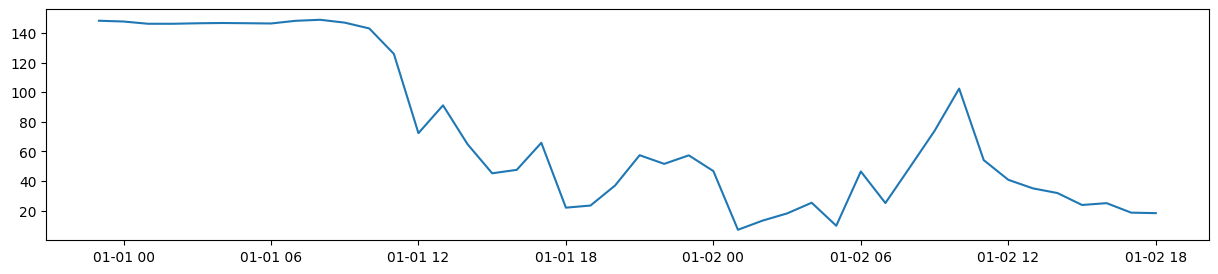

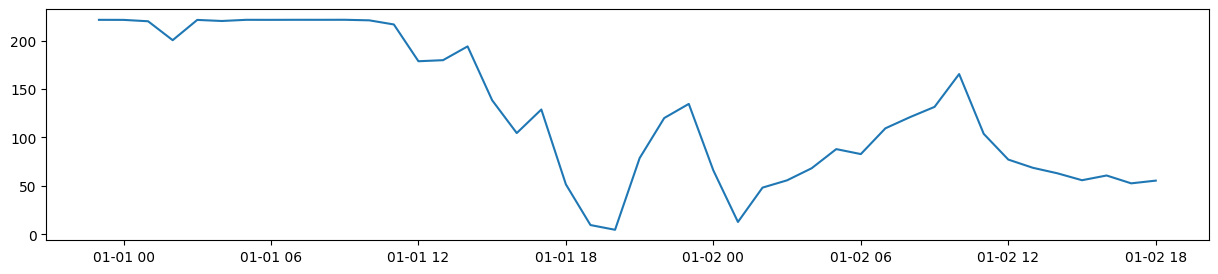

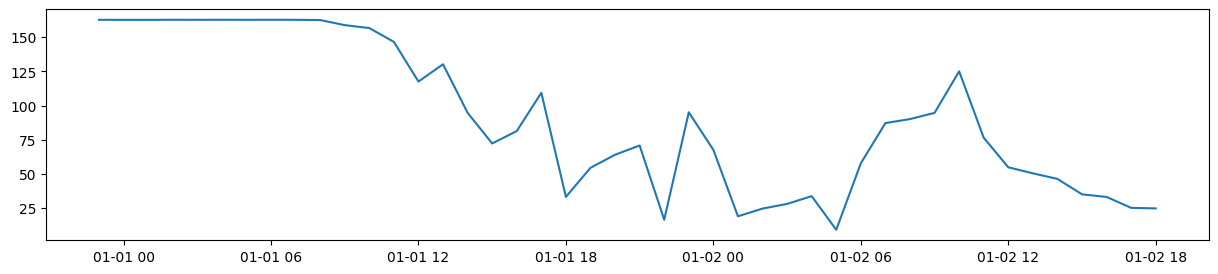

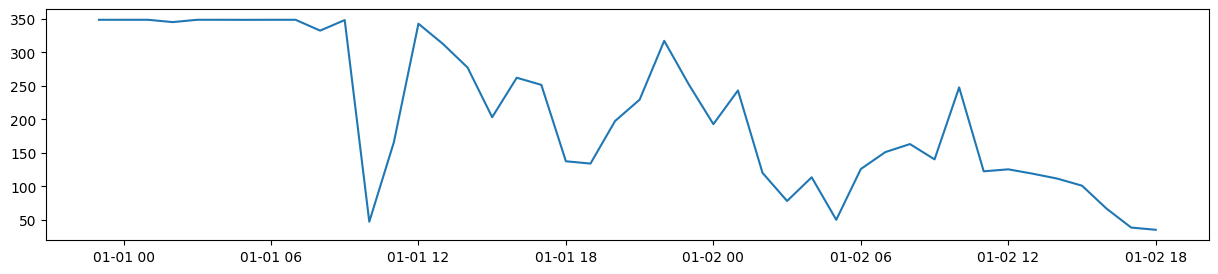

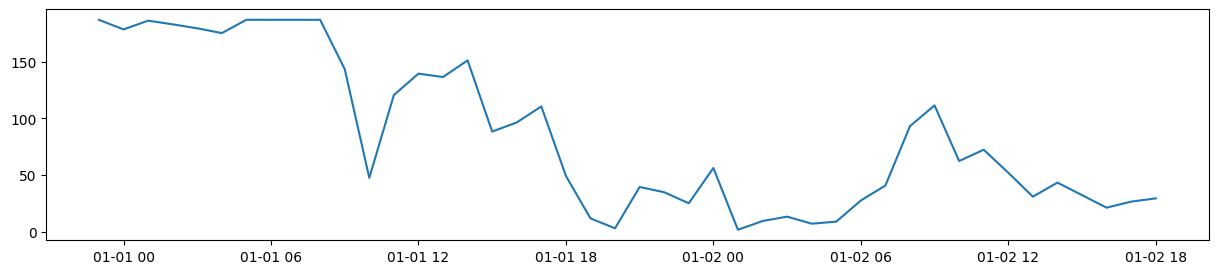

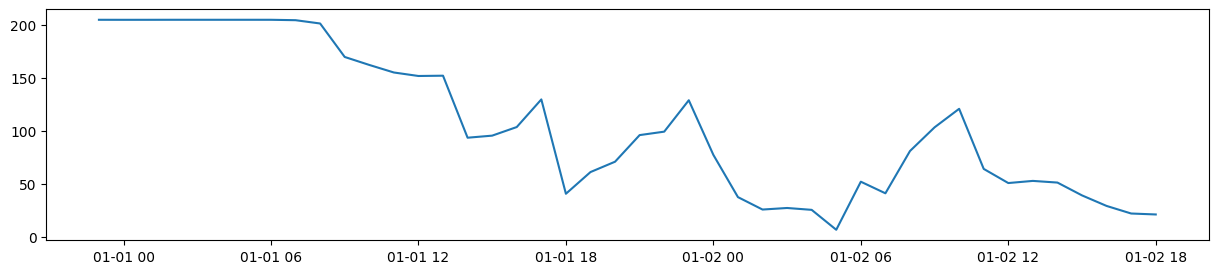

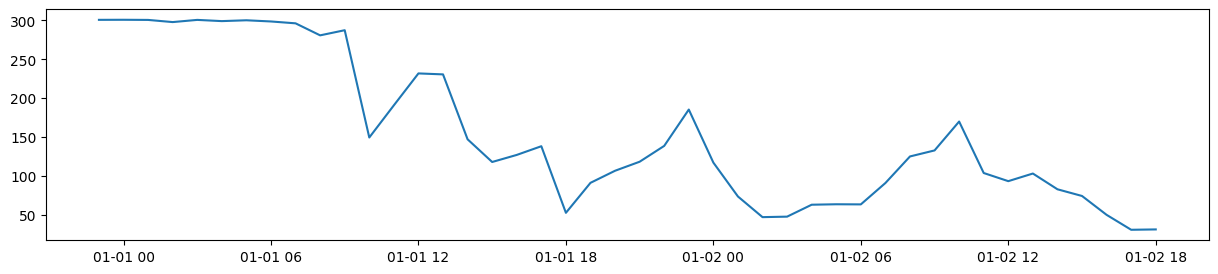

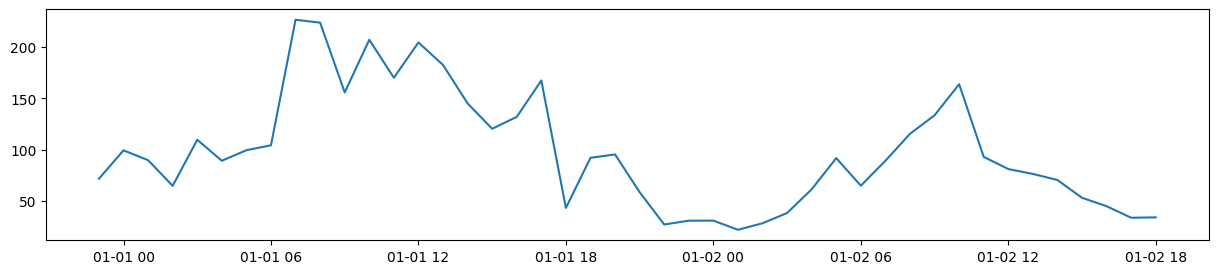

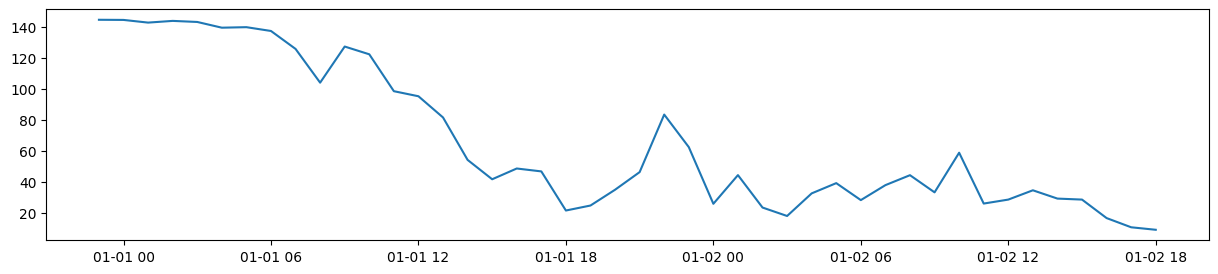

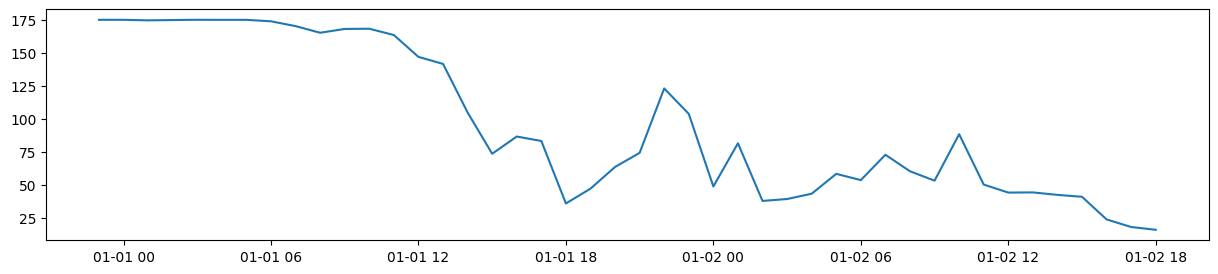

In [17]:
dict_series = {
    site: group.set_index('delivery_time')['production']
    for site, group in df_1.groupby('site_name')
}

for site in dict_series.keys():
    plt.figure(figsize=(15, 3))
    plt.plot(dict_series[site][:44])
    plt.show()


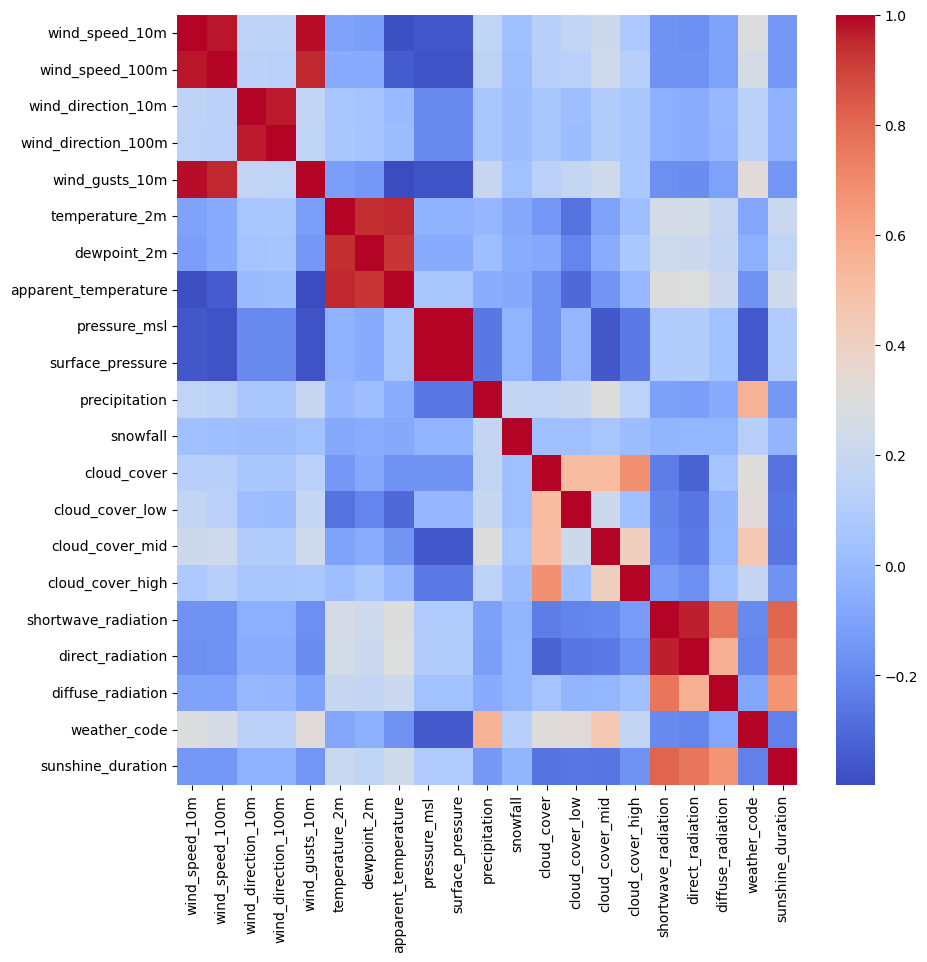

In [18]:
correlation_matrix = df_3.drop(columns=["site_name", "delivery_time"]).corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.show()

In [19]:
def get_site_name(idx:int, df_sites:pd.DataFrame):
    if idx >= len(df_sites):
        raise ValueError(f"They are only {len(df_sites)} sites")
    return df_sites['site_name'][idx]

In [20]:
df_prod = pd.read_parquet("data/dataset_1.parquet")
df_sites = pd.read_parquet("data/dataset_2.parquet")
df_weather = pd.read_parquet("data/dataset_3.parquet")

In [21]:
df_prod[df_prod.isnull().any(axis=1)]

,site_name,delivery_time,production,installed_capacity
39623,Rentel Offshore WP,2024-05-20 22:00:00+00:00,NaN,307.0
39624,Rentel Offshore WP,2024-05-20 23:00:00+00:00,NaN,307.0
39625,Rentel Offshore WP,2024-05-21 00:00:00+00:00,NaN,307.0
39626,Rentel Offshore WP,2024-05-21 01:00:00+00:00,NaN,307.0
39627,Rentel Offshore WP,2024-05-21 02:00:00+00:00,NaN,307.0
...,...,...,...,...
240044,Thorntonbank - C-Power - Area NE,2025-04-21 19:00:00+00:00,NaN,147.6
240045,Thorntonbank - C-Power - Area NE,2025-04-21 20:00:00+00:00,NaN,147.6
240046,Thorntonbank - C-Power - Area NE,2025-04-21 21:00:00+00:00,NaN,147.6
240047,Thorntonbank - C-Power - Area NE,2025-04-21 22:00:00+00:00,NaN,147.6


In [22]:
df_prod['production'] /= df_prod['installed_capacity']

In [23]:
site = get_site_name(0, df_sites)

df_prod_site_1 = df_prod[df_prod['site_name'] == site]
df_prod_site_1.columns

Index(['site_name', 'delivery_time', 'production', 'installed_capacity'], dtype='object')

In [24]:
df_prod_site_1['delivery_time']

0       2022-12-31 23:00:00+00:00
1       2023-01-01 00:00:00+00:00
2       2023-01-01 01:00:00+00:00
3       2023-01-01 02:00:00+00:00
4       2023-01-01 03:00:00+00:00
                   ...           
27475   2026-02-18 18:00:00+00:00
27476   2026-02-18 19:00:00+00:00
27477   2026-02-18 20:00:00+00:00
27478   2026-02-18 21:00:00+00:00
27479   2026-02-18 22:00:00+00:00
Name: delivery_time, Length: 27480, dtype: datetime64[ns, UTC]

In [25]:
df_prod["delivery_time"] = pd.to_datetime(df_prod["delivery_time"], utc=True)
df_weather["delivery_time"] = pd.to_datetime(df_weather["delivery_time"], utc=True)

df_merged = df_prod.merge(df_weather, on=["site_name","delivery_time"], how="inner")

In [26]:
df_merged.head()

,site_name,delivery_time,production,installed_capacity,wind_speed_10m,wind_speed_100m,wind_direction_10m,wind_direction_100m,wind_gusts_10m,temperature_2m,...,snowfall,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,shortwave_radiation,direct_radiation,diffuse_radiation,weather_code,sunshine_duration
0,Nobelwind Offshore Windpark,2023-01-01 00:00:00+00:00,0.985970,165.0,14.603082,19.897738,218.04709,219.28940,20.7,12.25,...,0.0,100.0,53.0,100.0,98.0,0.0,0.0,0.0,51.0,0.0
1,Nobelwind Offshore Windpark,2023-01-01 01:00:00+00:00,0.985939,165.0,16.182089,21.681328,215.94937,217.50421,20.8,12.10,...,0.0,100.0,18.0,100.0,100.0,0.0,0.0,0.0,51.0,0.0
2,Nobelwind Offshore Windpark,2023-01-01 02:00:00+00:00,0.986242,165.0,17.969420,23.809662,226.80397,228.74626,24.1,11.85,...,0.0,100.0,31.0,100.0,100.0,0.0,0.0,0.0,51.0,0.0
3,Nobelwind Offshore Windpark,2023-01-01 03:00:00+00:00,0.986136,165.0,14.792228,19.860010,227.46579,229.49266,23.9,11.80,...,0.0,100.0,27.0,24.0,100.0,0.0,0.0,0.0,3.0,0.0
4,Nobelwind Offshore Windpark,2023-01-01 04:00:00+00:00,0.986242,165.0,15.001333,19.915070,227.16109,228.86830,19.7,11.75,...,0.0,100.0,3.0,45.0,100.0,0.0,0.0,0.0,3.0,0.0


In [32]:
def compute_plateau(df, N=5, window="24h", tolerance=0.01, low_thresh=0.1, high_thresh=0.9):

    def count_similar_in_window(series, window, tol):
        # Déduire le pas temporel
        freq = series.index.to_series().diff().median()
        half_window = pd.Timedelta(window) / 2
        n_points = int(half_window / freq)  # nb de points de chaque côté
        
        values = series.values
        counts = np.array([
            np.sum(np.abs(values[max(0, i-n_points):i+n_points+1] - v) < tol)
            for i, v in enumerate(values)
        ])
        return pd.Series(counts, index=series.index)

    results = []
    for site, df_site in df.groupby("site_name"):
        df_site = df_site.sort_values("delivery_time").copy()
        df_site = df_site.set_index("delivery_time")

        p_max = df_site["production"].max()
        p_low = p_max * low_thresh
        p_high = p_max * high_thresh

        df_site["similar_count"] = count_similar_in_window(
            df_site["production"], window, tolerance)
        in_zone = (df_site["production"] >= p_low) & (
            df_site["production"] <= p_high)
        df_site["is_plateau"] = (df_site["similar_count"] >= N) & in_zone

        results.append(df_site.reset_index())

    return pd.concat(results, ignore_index=True)

In [33]:
df_merged = compute_plateau(df_merged)

In [34]:
def show_plateau(df, site_index, N=5, window="24h", tolerance=0.01, low_thresh=0.1, high_thresh=0.9):
    # Filtrer le site
    site_names = df["site_name"].unique()
    site = site_names[site_index]
    df_site_temp = df[df["site_name"] == site].sort_values("delivery_time").copy()
    df_site_temp = df_site_temp.set_index("delivery_time")

    p_max = df_site_temp["production"].max()
    p_low = p_max * low_thresh   # 10% du max
    p_high = p_max * high_thresh  # 90% du max
    
    # Pour chaque point, compter combien de valeurs identiques (à tolérance près)
    # apparaissent dans une fenêtre temporelle autour de lui
    def count_similar_in_window(series, window, tol):
        counts = []
        for t, v in series.items():
            window_vals = series[t - pd.Timedelta(window): t + pd.Timedelta(window)]
            similar = (window_vals - v).abs() < tol
            counts.append(similar.sum())
        return pd.Series(counts, index=series.index)

    df_site_temp["similar_count"] = count_similar_in_window(
        df_site_temp["production"], window, tolerance
    )
    in_zone = (df_site_temp["production"] >= p_low) & (df_site_temp["production"] <= p_high)
    df_site_temp["is_plateau"] = (df_site_temp["similar_count"] >= N) & in_zone
    
    # Plot
    df_site_temp = df_site_temp.reset_index()
    mask = df_site_temp["is_plateau"]
    plt.figure(figsize=(6, 6))
    plt.scatter(df_site_temp["wind_speed_100m"][~mask], df_site_temp["production"][~mask],
                c="tab:blue", s=1, label="Normal", alpha=0.2)
    plt.scatter(df_site_temp["wind_speed_100m"][mask], df_site_temp["production"][mask],
                c="tab:red", s=1, label=f">= {N} répétitions dans {window}", zorder=5, alpha=0.5)
    plt.title(f"Site: {site}")
    plt.xlabel("wind_speed_100m")
    plt.ylabel("production")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Site: {site} — {mask.sum()} points en plateau ({100*mask.mean():.1f}%)")
    
    # return df_site_temp

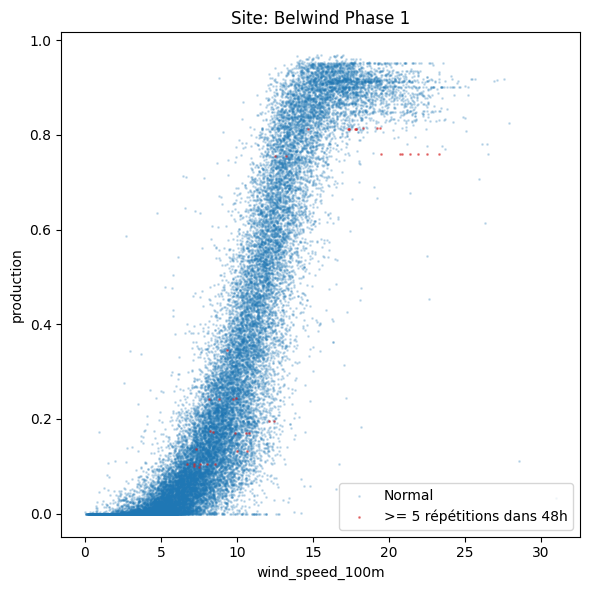

Site: Belwind Phase 1 — 41 points en plateau (0.1%)


In [35]:
show_plateau(df_merged, site_index=0, N=5, window="48h", tolerance=0.001, low_thresh=0.1, high_thresh=0.85)

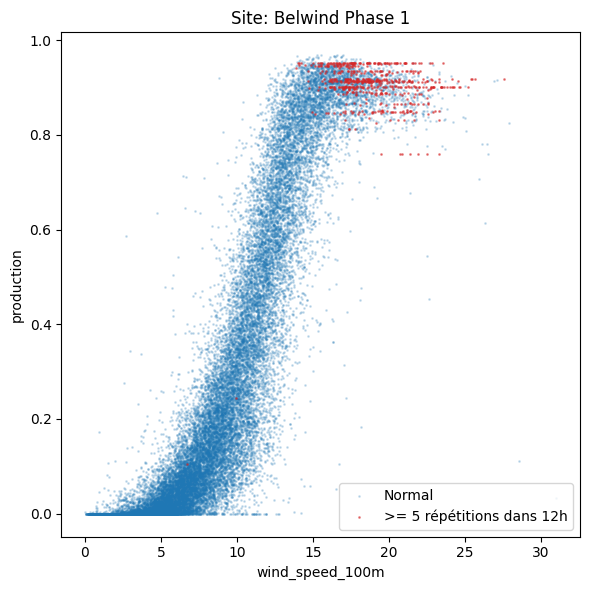

Site: Belwind Phase 1 — 577 points en plateau (2.1%)


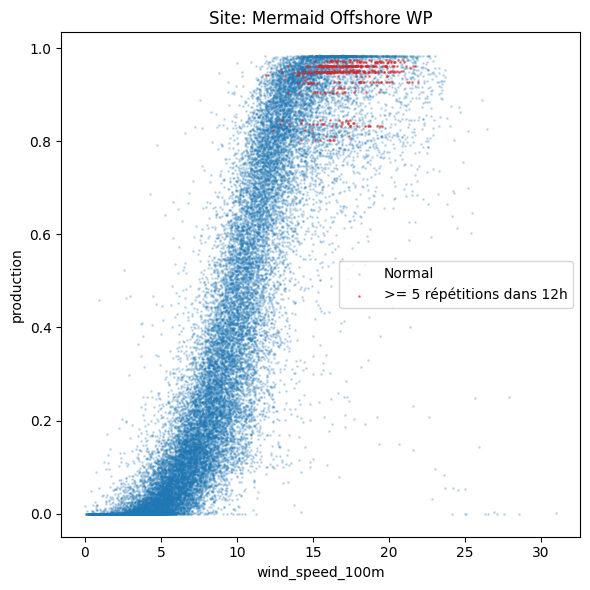

Site: Mermaid Offshore WP — 458 points en plateau (1.7%)


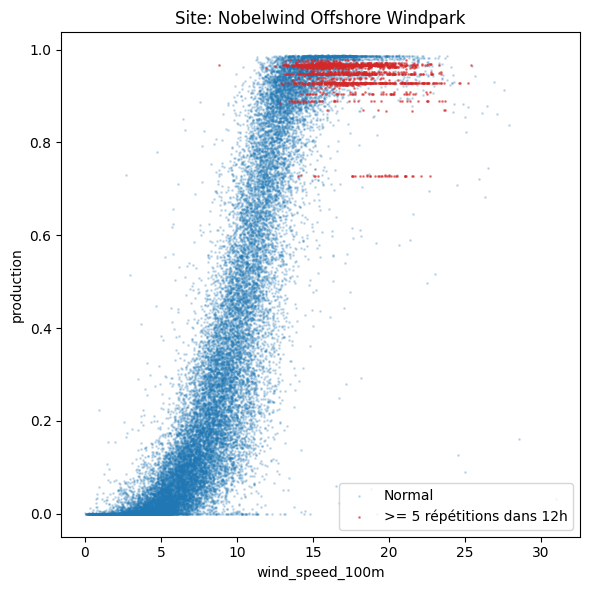

Site: Nobelwind Offshore Windpark — 1578 points en plateau (5.7%)


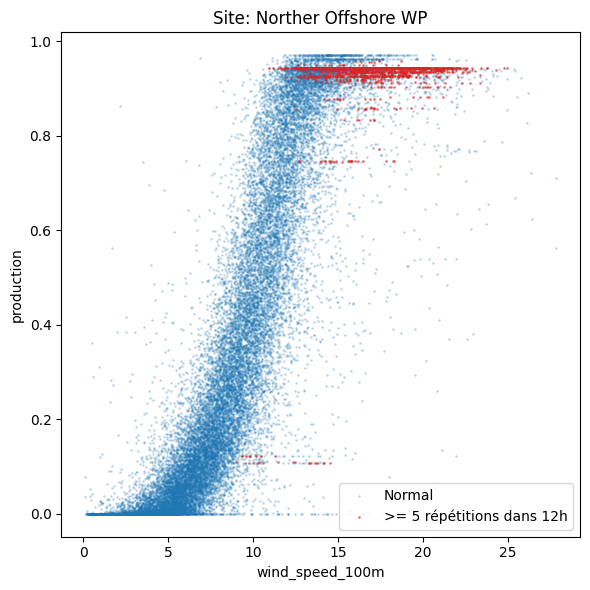

Site: Norther Offshore WP — 2075 points en plateau (7.6%)


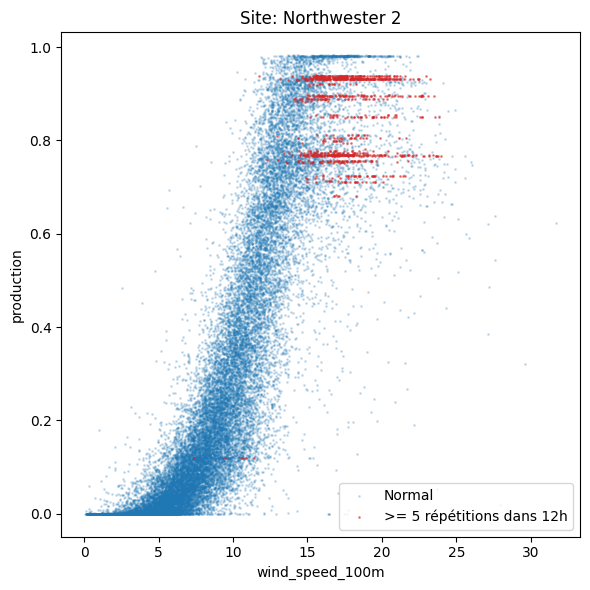

Site: Northwester 2 — 939 points en plateau (3.4%)


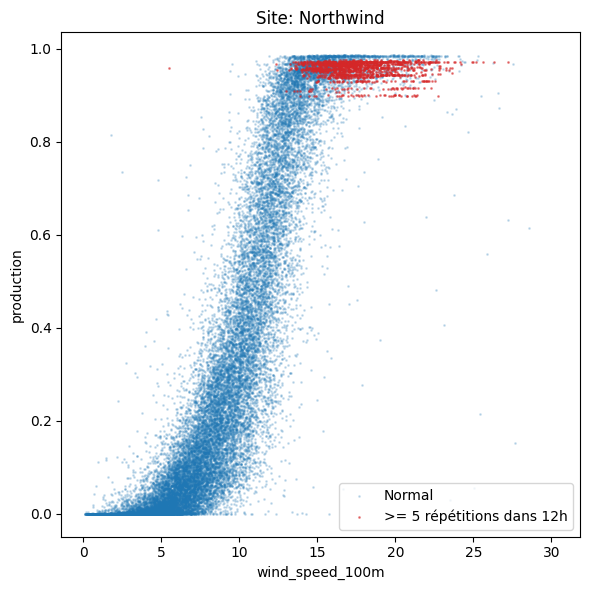

Site: Northwind — 1480 points en plateau (5.4%)


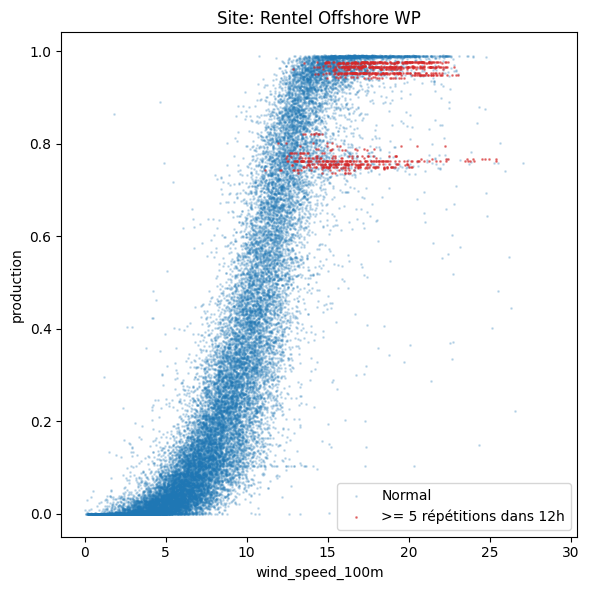

Site: Rentel Offshore WP — 908 points en plateau (3.3%)


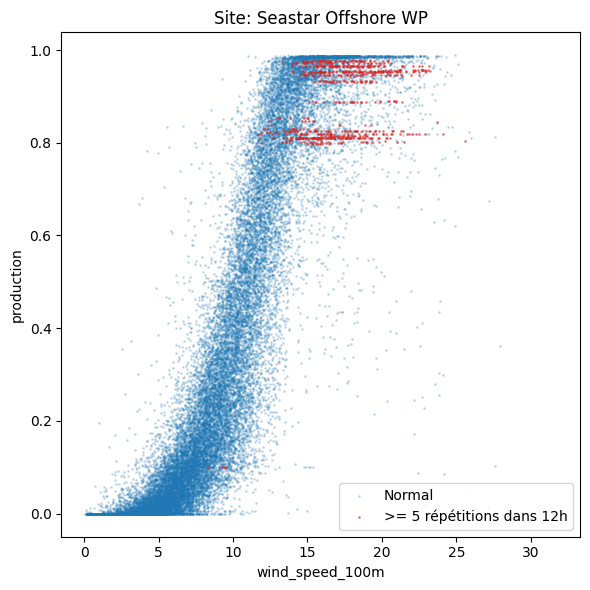

Site: Seastar Offshore WP — 715 points en plateau (2.6%)


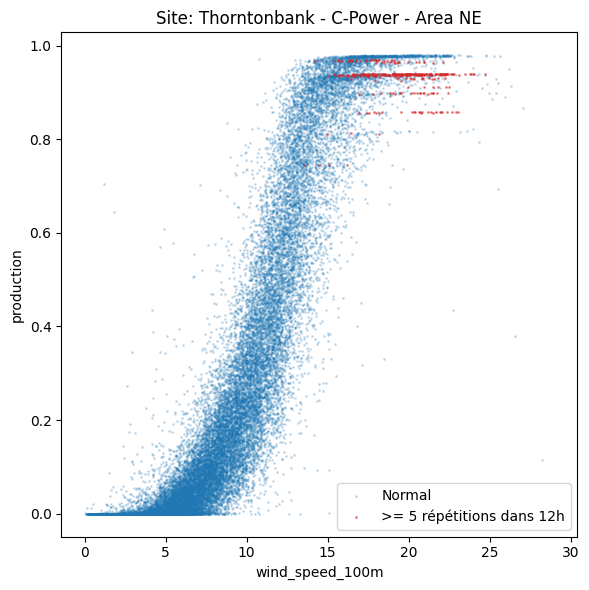

Site: Thorntonbank - C-Power - Area NE — 322 points en plateau (1.2%)


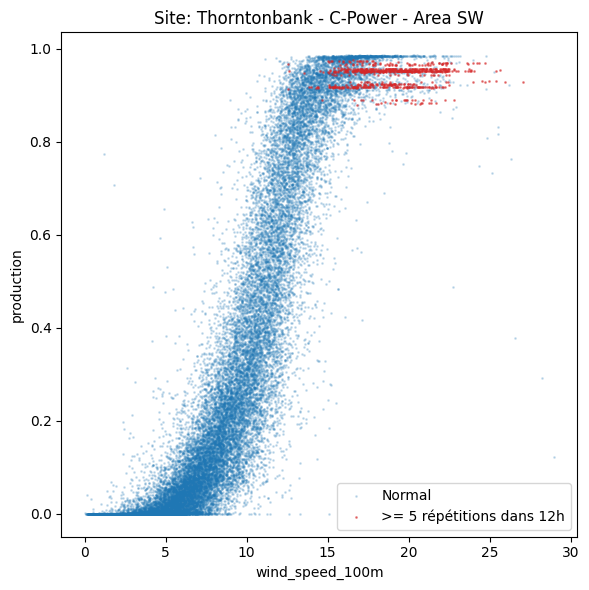

Site: Thorntonbank - C-Power - Area SW — 681 points en plateau (2.5%)


In [36]:
for i in range(10):
    show_plateau(df_merged, site_index=i, N=5, window="12h", tolerance=0.001, low_thresh=0.1, high_thresh=0.99)